## Introducción

En estos ejercicios vamos a trabajar con  datasets que representan el conjunto de personajes de Marvel en sus cómics con características de cada uno de ellos.

Las columnas del dataframe significan lo siguiente:

1. `page_id`: Identificador único de la página del personaje dentro de la wikia.
2. `name`: Nombre del personaje.
3. `urlslug`: URL única dentro de la wikia que lleva a la página del personaje.
4. `ID`: Estado de identidad del personaje (Identidad secreta, pública, o sin identidad dual en Marvel).
5. `ALIGN`: Alineación del personaje (Bueno, Malo o Neutral).
6. `EYE`: Color de ojos del personaje.
7. `HAIR`: Color de cabello del personaje.
8. `SEX`: Sexo del personaje (e.g. Masculino, Femenino, etc.).
9. `GSM`: Indica si el personaje pertenece a una minoría de género o sexual (e.g. Homosexual, Bisexual).
10. `ALIVE`: Indica si el personaje está vivo o fallecido.
11. `APPEARANCES`: Número de apariciones del personaje en cómics (al 2 de septiembre de 2014; el número puede estar desactualizado).
12. `FIRST APPEARANCE`: Mes y año de la primera aparición del personaje en un cómic, si está disponible.
13. `YEAR`: Año de la primera aparición del personaje en un cómic, si está disponible.



# Parte 1: Extracción de Datos

Concatena todas las fuentes en un solo Dataset , añade para cada fuente una columna , que indique el origen, a fin de que cuando se concatenen poder tener trazabilidad sobre el origen de donde vino el dato. Para MongoDB usa Mongo Compass


In [ ]:
import pandas as pd
import sqlite3
import pyodbc
from pymongo import MongoClient

In [102]:
# Archivo TXT
df_txt = pd.read_csv('./fuentes marvel/marvel_characters.txt', sep=';')

df_txt = df_txt.rename(columns={
    'ID': 'page_id',
    'Name': 'name',
    'URL': 'urlslug',
    'Identity': 'ID',
    'Alignment': 'ALIGN',
    'Eyes': 'EYE',
    'Hair': 'HAIR',
    'Sex': 'SEX',
    'GSM': 'GSM',
    'Status': 'ALIVE',
    'Appearances': 'APPEARANCES',
    'First_Appearance': 'FIRST APPEARANCE',
    'Year': 'Year'
})
display(df_txt.head(3))
print(len(df_txt))

,page_id,name,urlslug,ID,ALIGN,EYE,HAIR,SEX,GSM,ALIVE,APPEARANCES,FIRST APPEARANCE,Year
0,1678,Spider-Man (Peter Parker),\/Spider-Man_(Peter_Parker),Secret Identity,Good Characters,Hazel Eyes,Brown Hair,Male Characters,NaN,Living Characters,4043.0,NaN,1962.0
1,7139,Captain America (Steven Rogers),\/Captain_America_(Steven_Rogers),Public Identity,Good Characters,Blue Eyes,White Hair,Male Characters,NaN,Living Characters,3360.0,NaN,1941.0
2,64786,"Wolverine (James \""Logan\"" Howlett)",\/Wolverine_(James_%22Logan%22_Howlett),Public Identity,Neutral Characters,Blue Eyes,Black Hair,Male Characters,NaN,Living Characters,3061.0,NaN,1974.0


16376


In [ ]:
# Archivo XLSX
df_xlsx = pd.read_excel('./fuentes marvel/marvel_characters.xlsx')
display(df_xlsx.head(3))
print(len(df_xlsx))

,page_id,name,urlslug,ID,ALIGN,EYE,HAIR,SEX,GSM,ALIVE,APPEARANCES,FIRST APPEARANCE,Year
0,1678,Spider-Man (Peter Parker),\/Spider-Man_(Peter_Parker),Secret Identity,Good Characters,Hazel Eyes,Brown Hair,Male Characters,NaN,Living Characters,4043.0,Aug-62,1962.0
1,7139,Captain America (Steven Rogers),\/Captain_America_(Steven_Rogers),Public Identity,Good Characters,Blue Eyes,White Hair,Male Characters,NaN,Living Characters,3360.0,Mar-41,1941.0
2,64786,"Wolverine (James \""Logan\"" Howlett)",\/Wolverine_(James_%22Logan%22_Howlett),Public Identity,Neutral Characters,Blue Eyes,Black Hair,Male Characters,NaN,Living Characters,3061.0,Oct-74,1974.0


16376


In [ ]:
# Archivo JSON
df_json = pd.json_normalize(
    pd.read_json("./fuentes marvel/marvel_api_response.json", typ="series")["data"]
)
display(df_json.head(3))
print(len(df_json))

,page_id,name,urlslug,ID,ALIGN,EYE,HAIR,SEX,GSM,ALIVE,APPEARANCES,FIRST APPEARANCE,Year
0,1678,Spider-Man (Peter Parker),\/Spider-Man_(Peter_Parker),Secret Identity,Good Characters,Hazel Eyes,Brown Hair,Male Characters,,Living Characters,4043.0,Aug-62,1962.0
1,7139,Captain America (Steven Rogers),\/Captain_America_(Steven_Rogers),Public Identity,Good Characters,Blue Eyes,White Hair,Male Characters,,Living Characters,3360.0,Mar-41,1941.0
2,64786,"Wolverine (James \""Logan\"" Howlett)",\/Wolverine_(James_%22Logan%22_Howlett),Public Identity,Neutral Characters,Blue Eyes,Black Hair,Male Characters,,Living Characters,3061.0,Oct-74,1974.0


16376


In [ ]:
# Archivo SQLite
conn = sqlite3.connect('./fuentes marvel/marvel_sqlite.db')
df_sqlite = pd.read_sql('SELECT * FROM marvel_characters', conn)
conn.close()
display(df_sqlite.head(3))
display(len(df_sqlite))

,page_id,name,urlslug,ID,ALIGN,EYE,HAIR,SEX,GSM,ALIVE,APPEARANCES,FIRST APPEARANCE,Year
0,1678,Spider-Man (Peter Parker),\/Spider-Man_(Peter_Parker),Secret Identity,Good Characters,Hazel Eyes,Brown Hair,Male Characters,,Living Characters,4043.0,Aug-62,1962.0
1,7139,Captain America (Steven Rogers),\/Captain_America_(Steven_Rogers),Public Identity,Good Characters,Blue Eyes,White Hair,Male Characters,,Living Characters,3360.0,Mar-41,1941.0
2,64786,"Wolverine (James \""Logan\"" Howlett)",\/Wolverine_(James_%22Logan%22_Howlett),Public Identity,Neutral Characters,Blue Eyes,Black Hair,Male Characters,,Living Characters,3061.0,Oct-74,1974.0


16376

In [36]:
# SQL Server
conexion_sqlserver = pyodbc.connect (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=DESKTOP-G71OM7J;"
    "DATABASE=master;"
    "Trusted_Connection=yes;"
)

df_sqlserver = pd.read_sql("SELECT * FROM marvel_characters", conexion_sqlserver)
df_sqlserver = df_sqlserver.rename(columns={'FIRST_APPEARANCE': 'FIRST APPEARANCE'}) 
conexion_sqlserver.close()

display(df_sqlserver.head(3))
display(len(df_sqlserver))


C:\Users\merce\AppData\Local\Temp\ipykernel_17716\3118204355.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_sqlserver = pd.read_sql("SELECT * FROM marvel_characters", conexion_sqlserver)


,page_id,name,urlslug,ID,ALIGN,EYE,HAIR,SEX,GSM,ALIVE,APPEARANCES,FIRST APPEARANCE,Year
0,1025,Emil Blonsky (Earth-616),\/Emil_Blonsky_(Earth-616),Secret Identity,Bad Characters,Blue Eyes,Blond Hair,Male Characters,NULL,Living Characters,115.0,Apr-67,1967.0
1,1026,Absalom (Earth-616),\/Absalom_(Earth-616),Secret Identity,NULL,Blue Eyes,Blond Hair,Male Characters,NULL,Deceased Characters,6.0,May-92,1992.0
2,1027,Carl Creel (Earth-616),\/Carl_Creel_(Earth-616),Public Identity,Bad Characters,Blue Eyes,Bald,Male Characters,NULL,Living Characters,202.0,Apr-64,1964.0


16376

In [21]:
with MongoClient("mongodb://localhost:27017/") as client:
    docs = list(client["Marvel"]["marvel"].find({}))

df_mongo = pd.DataFrame(docs)
df_mongo = df_mongo.drop(columns=['_id'])

display(df_mongo.head(3))
display(len(df_mongo))

,page_id,name,urlslug,ID,ALIGN,EYE,HAIR,SEX,GSM,ALIVE,APPEARANCES,FIRST APPEARANCE,Year
0,1678,Spider-Man (Peter Parker),\/Spider-Man_(Peter_Parker),Secret Identity,Good Characters,Hazel Eyes,Brown Hair,Male Characters,None,Living Characters,4043.0,Aug-62,1962.0
1,7139,Captain America (Steven Rogers),\/Captain_America_(Steven_Rogers),Public Identity,Good Characters,Blue Eyes,White Hair,Male Characters,None,Living Characters,3360.0,Mar-41,1941.0
2,64786,"Wolverine (James \""Logan\"" Howlett)",\/Wolverine_(James_%22Logan%22_Howlett),Public Identity,Neutral Characters,Blue Eyes,Black Hair,Male Characters,None,Living Characters,3061.0,Oct-74,1974.0


16376

In [49]:
df_total = pd.concat([df_txt, df_xlsx, df_json, df_sqlite, df_sqlserver, df_mongo], ignore_index=True)
print(f"Dataframe concatenado: {len(df_total)} registros")
display(df_total.head())
display(len(df_total))

Dataframe concatenado: 98256 registros


,page_id,name,urlslug,ID,ALIGN,EYE,HAIR,SEX,GSM,ALIVE,APPEARANCES,FIRST APPEARANCE,Year
0,1678,Spider-Man (Peter Parker),\/Spider-Man_(Peter_Parker),Secret Identity,Good Characters,Hazel Eyes,Brown Hair,Male Characters,NaN,Living Characters,4043.0,NaN,1962.0
1,7139,Captain America (Steven Rogers),\/Captain_America_(Steven_Rogers),Public Identity,Good Characters,Blue Eyes,White Hair,Male Characters,NaN,Living Characters,3360.0,NaN,1941.0
2,64786,"Wolverine (James \""Logan\"" Howlett)",\/Wolverine_(James_%22Logan%22_Howlett),Public Identity,Neutral Characters,Blue Eyes,Black Hair,Male Characters,NaN,Living Characters,3061.0,NaN,1974.0
3,1868,"Iron Man (Anthony \""Tony\"" Stark)",\/Iron_Man_(Anthony_%22Tony%22_Stark),Public Identity,Good Characters,Blue Eyes,Black Hair,Male Characters,NaN,Living Characters,2961.0,NaN,1963.0
4,2460,Thor (Thor Odinson),\/Thor_(Thor_Odinson),No Dual Identity,Good Characters,Blue Eyes,Blond Hair,Male Characters,NaN,Living Characters,2258.0,NaN,1950.0


98256

# Parte 2: Análisis Exploratorio y Limpieza de Datos

En esta sección el estudiante debe realizar el análisis exploratorio de datos (EDA), se detectarán outliers, se limpiará el dataset y se responderán preguntas sobre los datos.


## 2.1 EDA Inicial

Se realiza un análisis exploratorio inicial del dataset para comprender su estructura, tipos de datos, cantidad de valores nulos y estadísticas descriptivas básicas.


In [50]:
print("=== ESTRUCTURA DEL DATASET ===")
print(df_total.info())

print("\n=== TIPOS DE DATOS ===")
display(df_total.dtypes)

print("\n=== PORCENTAJE DE VALORES NULOS POR COLUMNA ===")
display((df_total.isnull().sum() / len(df_total)) * 100)

print("\n=== ESTADÍSTICAS DESCRIPTIVAS ===")
display(df_total.describe())

=== ESTRUCTURA DEL DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98256 entries, 0 to 98255
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   page_id           98256 non-null  int64 
 1   name              98256 non-null  object
 2   urlslug           98256 non-null  object
 3   ID                86946 non-null  object
 4   ALIGN             89820 non-null  object
 5   EYE               68955 non-null  object
 6   HAIR              85464 non-null  object
 7   SEX               95694 non-null  object
 8   GSM               49398 non-null  object
 9   ALIVE             98247 non-null  object
 10  APPEARANCES       93872 non-null  object
 11  FIRST APPEARANCE  80250 non-null  object
 12  Year              94996 non-null  object
dtypes: int64(1), object(12)
memory usage: 9.7+ MB
None

=== TIPOS DE DATOS ===


page_id              int64
name                object
urlslug             object
ID                  object
ALIGN               object
EYE                 object
HAIR                object
SEX                 object
GSM                 object
ALIVE               object
APPEARANCES         object
FIRST APPEARANCE    object
Year                object
dtype: object


=== PORCENTAJE DE VALORES NULOS POR COLUMNA ===


page_id              0.000000
name                 0.000000
urlslug              0.000000
ID                  11.510747
ALIGN                8.585735
EYE                 29.821080
HAIR                13.019052
SEX                  2.607474
GSM                 49.725208
ALIVE                0.009160
APPEARANCES          4.461814
FIRST APPEARANCE    18.325598
Year                 3.317864
dtype: float64


=== ESTADÍSTICAS DESCRIPTIVAS ===


,page_id
count,98256.000000
mean,300232.082377
std,253453.954271
min,1025.000000
25%,28309.500000
50%,282578.000000
75%,509077.000000
max,755278.000000


### Gráfico 1: Distribución por Alineación (ALIGN)

Visualiza cuántos personajes hay de cada tipo de alineación (Bueno, Malo, Neutral, etc.).


C:\Users\merce\AppData\Local\Temp\ipykernel_17716\2664870381.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_total, x="ALIGN", order=df_total["ALIGN"].value_counts().index, palette='viridis')


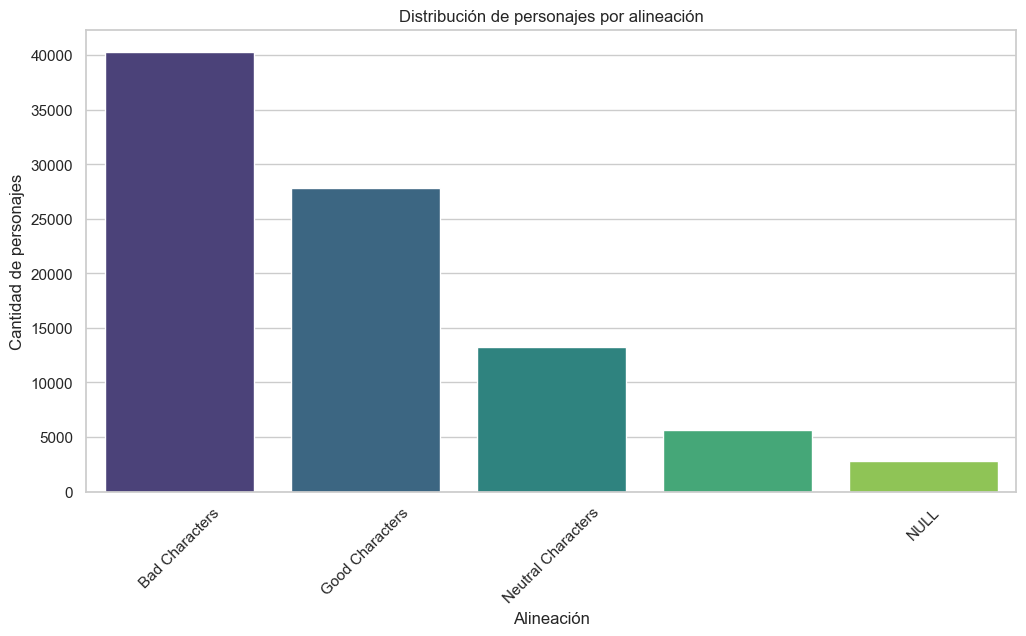

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.set_theme(style='whitegrid')
plt.figure(figsize=(12, 6))

if "ALIGN":
    sns.countplot(data=df_total, x="ALIGN", order=df_total["ALIGN"].value_counts().index, palette='viridis')
    plt.title("Distribución de personajes por alineación")
    plt.xlabel("Alineación")
    plt.ylabel("Cantidad de personajes")
    plt.xticks(rotation=45)
    plt.show()
    

En la distribución de alineaciones sin limpiar, "Bad Characters" es la categoría con mayor presencia en la tabla, seguida de "Good Characters" y luego "Neutral Characters". Además, aparecen valores problemáticos como '' (cadena vacía) y NULL, que representan datos faltantes y deben ser limpiados para no distorsionar el análisis. 


## 2.2 Cálculo de Outliers




In [56]:
# Convertir columnas numéricas a número primero
df_total['APPEARANCES'] = pd.to_numeric(df_total['APPEARANCES'], errors='coerce')
df_total['Year'] = pd.to_numeric(df_total['Year'], errors='coerce')

#seleccionar solo las columnas numericas del dataframe 'compras'
columnas_numericas = df_total.select_dtypes(include = 'number').columns

#lista donde se guardara el resumen de outliers por cada columna
resumen_outliers = []

#Recorrer cada columna numerica para calcular sus limites de outliers
for col in columnas_numericas:
    #Q1: percentil 25
    q1 = df_total[col].quantile(0.25)
    #Q3: percentil 75%
    q3 = df_total[col].quantile(0.75)
    #Rango intercuantilico IQR
    iqr = q3-q1
    
    #limites oara detectar outliers segun la regla q1-1.5*IQR / q3+1.5*IQR
    lim_inf = max(0,q1 - 1.5 * iqr)

    lim_sup = q3 + 1.5 * iqr

    #filtrar las filas con valores fuera de lso limites(es decir son outliers)
    outliers = df_total[(df_total[col] < lim_inf) | (df_total[col] > lim_sup)]

    #Guardar resumen de etadisticas en la lista
    resumen_outliers.append({
        "columna": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "limite_inferior": lim_inf,
        "limite_superior": lim_sup,
        "cantidad_outliers": outliers.shape[0]
    })
#convertir la lista de diccionario en dataframe y ordenar por cantidad de outliers(mayor a menor)

pd.DataFrame(resumen_outliers).sort_values("cantidad_outliers", ascending=False)


,columna,Q1,Q3,IQR,limite_inferior,limite_superior,cantidad_outliers
1,APPEARANCES,1.0,8.0,7.0,0.0,18.50,11628
0,page_id,28309.5,509077.0,480767.5,0.0,1230228.25,0
2,Year,1974.0,2000.0,26.0,1935.0,2039.00,0


### Gráfico 3: Diagrama BoxPlot 

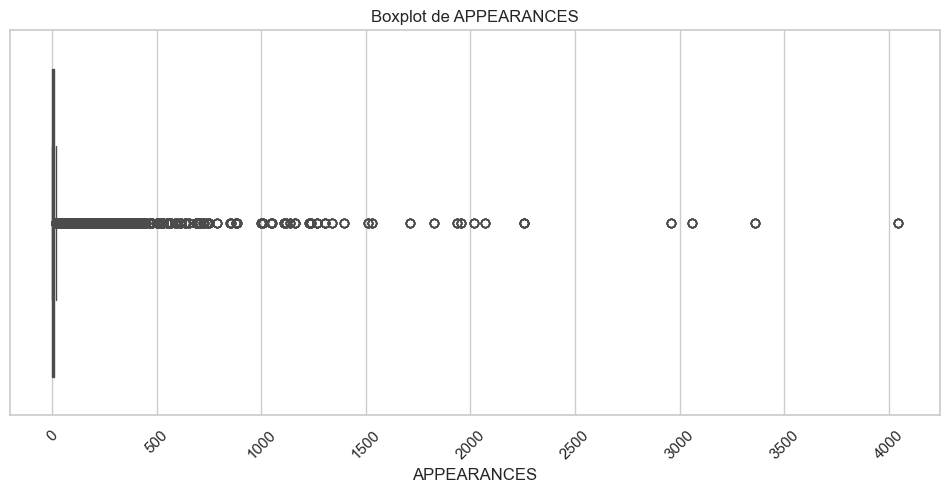

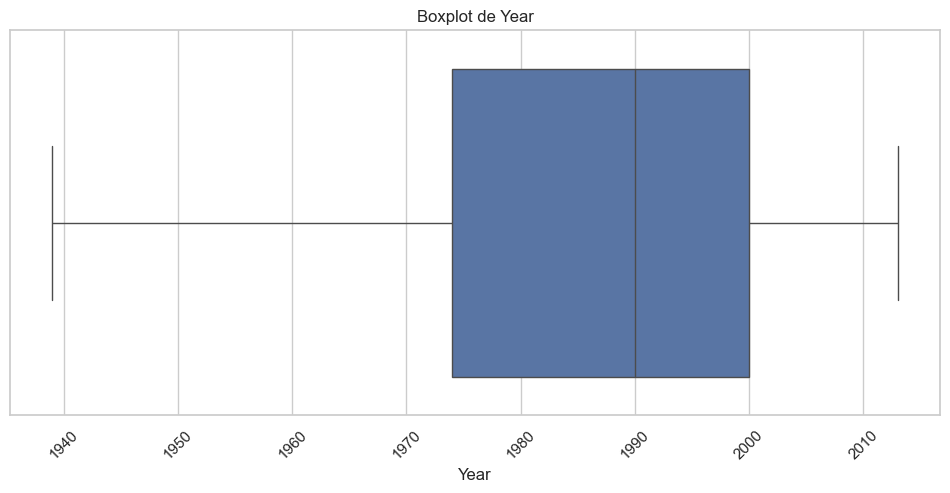

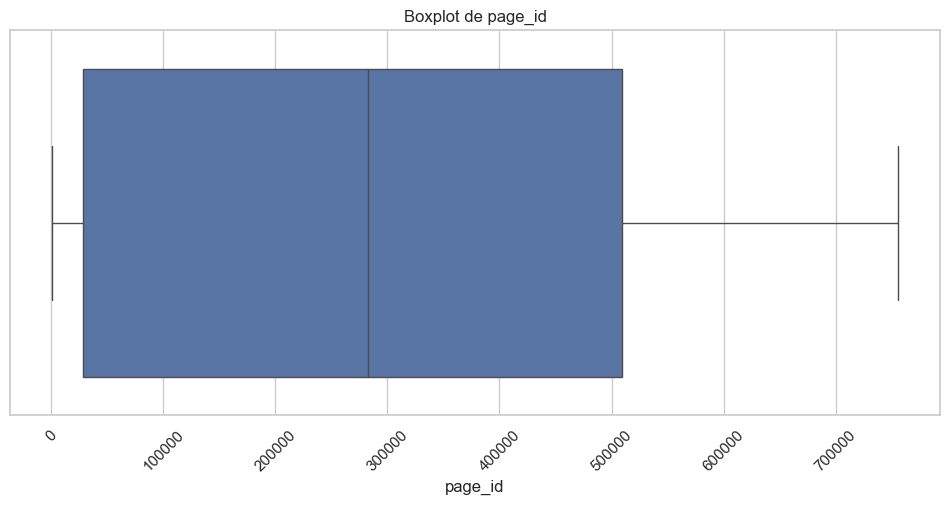

In [57]:
num_cols_graficas = ['APPEARANCES', 'Year', 'page_id']

for col in num_cols_graficas:
    if col in df_total.columns:
        plt.figure(figsize=(12, 5))
        sns.boxplot(x=df_total[col])
        plt.title(f"Boxplot de {col}")
        plt.xticks(rotation=45)
        plt.show()

### Gráfico 4: Diagrama de densidad de núcleo (KDE)

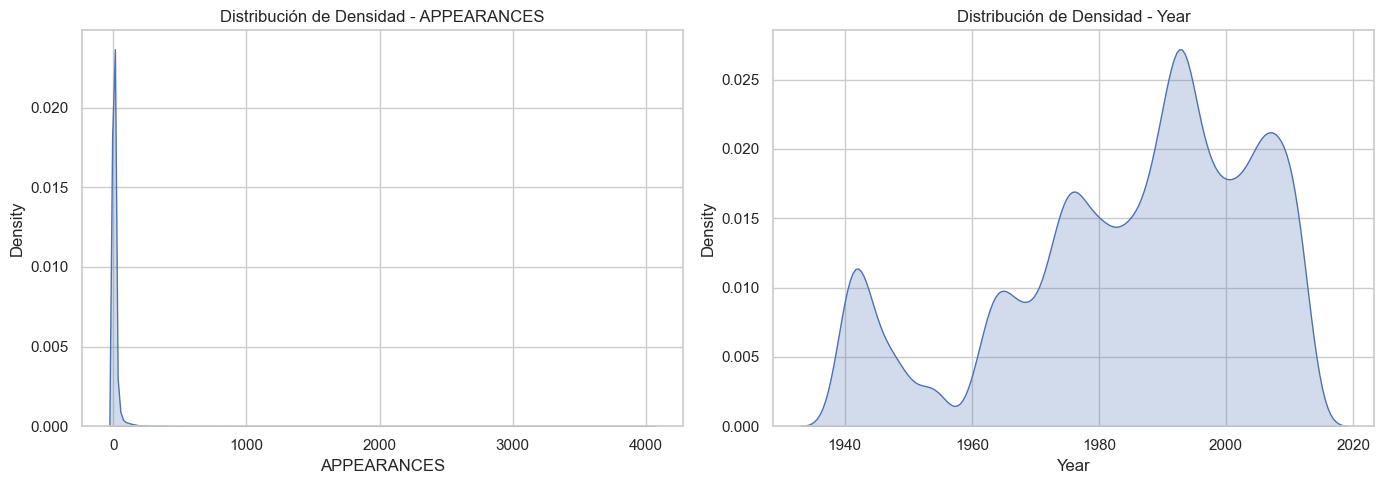

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(['APPEARANCES', 'Year']):
    if col in df_total.columns:
        sns.kdeplot(data=df_total, x=col, fill=True, ax=axes[i])
        axes[i].set_title(f'Distribución de Densidad - {col}')
        axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

## 2.3 Limpieza de Datos

Se debe aplicar los siguientes pasos de limpieza:

- **Eliminar duplicados** exactos del dataset.
- **Imputar valores nulos** en columnas categóricas con `'Desconocido'`.
- **Imputar valores nulos** en columnas numéricas con la **mediana** de la columna.


In [60]:
# 1. Eliminar duplicados exactos
duplicados_antes = len(df_total)
df_total = df_total.drop_duplicates()
print(f"Duplicados eliminados: {duplicados_antes - len(df_total)}")

# 2. Imputar valores nulos en columnas categóricas con 'Desconocido'
columnas_categoricas = ['ID', 'ALIGN', 'EYE', 'HAIR', 'SEX', 'GSM', 'ALIVE', 'FIRST APPEARANCE']

for col in columnas_categoricas:
    if col in df_total.columns:
        df_total[col] = df_total[col].fillna('Desconocido')
        df_total[col] = df_total[col].replace(['NULL', 'None', '', 'nan', 'NaN'], 'Desconocido')

print("Categóricas limpiadas")

# 3. Imputar valores nulos en columnas numéricas con la MEDIANA
for col in ['APPEARANCES', 'Year']:
    if col in df_total.columns:
        mediana = df_total[col].median()
        df_total[col] = df_total[col].fillna(mediana)
        print(f"Columna {col}: valores nulos imputados con mediana = {mediana}")

print("\n=== VERIFICACIÓN: Valores nulos restantes ===")
display(df_total.isnull().sum())

Duplicados eliminados: 31000
Categóricas limpiadas
Columna APPEARANCES: valores nulos imputados con mediana = 3.0
Columna Year: valores nulos imputados con mediana = 1989.0

=== VERIFICACIÓN: Valores nulos restantes ===


page_id             0
name                0
urlslug             0
ID                  0
ALIGN               0
EYE                 0
HAIR                0
SEX                 0
GSM                 0
ALIVE               0
APPEARANCES         0
FIRST APPEARANCE    0
Year                0
dtype: int64

Consulta y responde, para imputar valores nulos en columnas numericas, cuando es recomendable hacerlo con la media, la mediana, la moda o talvez existen alguna otra técnica?. Responde para cada caso cuando es recomendable

## 2.4 EDA PROFUNDO

Ejercicio 1. Comparación de personajes por década de creación  
Crea una columna de décadas a partir de YEAR.  
Cuenta cuántos personajes fueron creados en cada década.  
Identifica las décadas con mayor número de personajes.  
Realiza una breve interpretación de la evolución de creación de personajes a lo largo del tiempo.  



=== PERSONAJES POR DÉCADA ===
DECADE
1930     138
1940    2882
1950     604
1960    2612
1970    4468
1980    7295
1990    7314
2000    6172
2010    2082
Name: count, dtype: Int64

=== TOP 3 DÉCADAS CON MÁS PERSONAJES ===
Década 1990s: 7314 personajes
Década 1980s: 7295 personajes
Década 2000s: 6172 personajes


C:\Users\merce\AppData\Local\Temp\ipykernel_17716\1870606562.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=decade_counts.index.astype(str), y=decade_counts.values, palette='coolwarm')


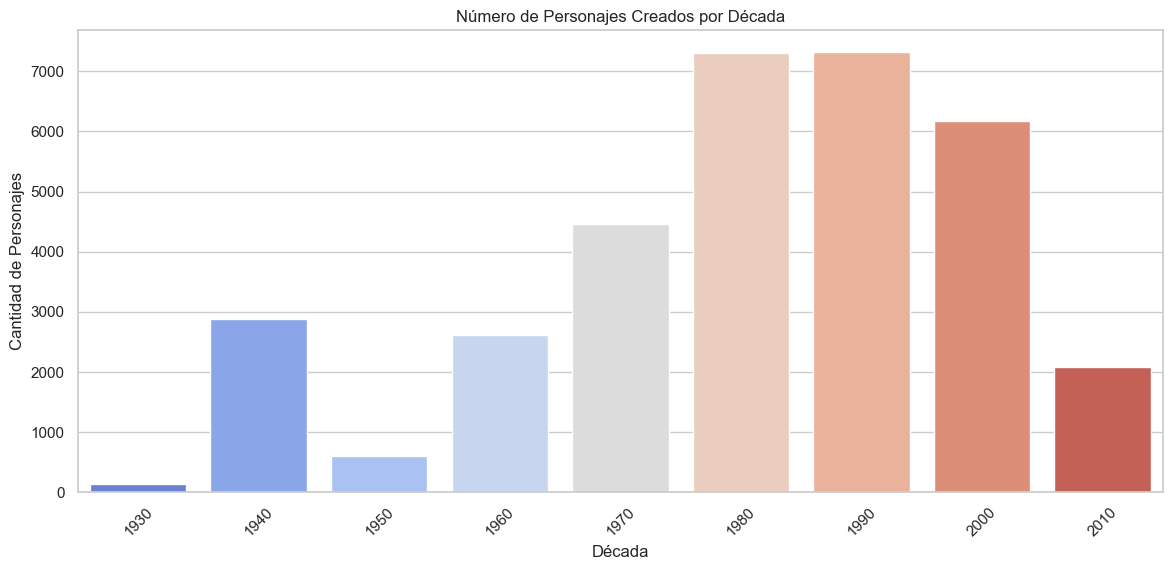

In [ ]:
# Crear columna de década
df_total['DECADE'] = (df_total['Year'] // 10) * 10
df_total['DECADE'] = df_total['DECADE'].astype('Int64')

# Contar personajes por década
decade_counts = df_total['DECADE'].value_counts().sort_index()

print("=== PERSONAJES POR DÉCADA ===")
print(decade_counts)

# Top 3 décadas
top_decades = decade_counts.nlargest(3)
print(f"\n=== TOP 3 DÉCADAS CON MÁS PERSONAJES ===")
for decade, count in top_decades.items():
    print(f"Década {decade}s: {count} personajes")



## 2.5 Preguntas

Responde las siguientes preguntas utilizando el dataset limpio:

1. ¿Cuántos personajes están vivos y cuántos han fallecido?
2. ¿Cuál es el color de cabello más común entre los personajes buenos?
3. ¿Qué porcentaje de personajes tiene identidad secreta?
4. ¿Cuál fue el año en que se crearon más personajes?


In [62]:
# 1. ¿Cuántos personajes están vivos y cuántos han fallecido?
print("=== PREGUNTA 1 ===")
print(df_total['ALIVE'].value_counts())


=== PREGUNTA 1 ===
ALIVE
Living Characters      25903
Deceased Characters     7655
Desconocido                9
Name: count, dtype: int64


Hay 25903 personajes que estan vivos, 7655 estan muertos y el paradero de 9 de ellos es desconocido

In [63]:
# 2. ¿Cuál es el color de cabello más común entre los personajes buenos?
print("\n=== PREGUNTA 2 ===")
good_characters = df_total[df_total['ALIGN'] == 'Good Characters']
hair_counts = good_characters['HAIR'].value_counts()
print(f"Color de cabello más común entre personajes buenos: {hair_counts.index[0]}")
print(f"Frecuencia: {hair_counts.iloc[0]} personajes")


=== PREGUNTA 2 ===
Color de cabello más común entre personajes buenos: Black Hair
Frecuencia: 2359 personajes


In [66]:
# 3. ¿Qué porcentaje de personajes tiene identidad secreta?
print("\n=== PREGUNTA 3 ===")
secret_count = len(df_total[df_total['ID'] == 'Secret Identity'])
porcentaje_secret = (secret_count / len(df_total)) * 100
print(f"Porcentaje de personajes con identidad secreta: {porcentaje_secret:.2f}%")


=== PREGUNTA 3 ===
Porcentaje de personajes con identidad secreta: 38.28%


In [65]:
# 4. ¿Cuál fue el año en que se crearon más personajes?
print("\n=== PREGUNTA 4 ===")
year_counts = df_total['Year'].value_counts()
top_year = year_counts.index[0]
print(f"Año con más personajes creados: {int(top_year)}")
print(f"Cantidad: {year_counts.iloc[0]} personajes")


=== PREGUNTA 4 ===
Año con más personajes creados: 1989
Cantidad: 3087 personajes


# Parte 3: Visualización de Datos(COMUNICACION DE INFORMACIÓN)


### EJERCICIO 1. Gráfico de tendencia: Evolución de la cantidad de personajes creados por año

- Analiza la cantidad de personajes creados cada año (YEAR).
- Crea un gráfico de línea que muestre la evolución del número de personajes creados a lo largo del tiempo.
- Realiza una interpretación del gráfico


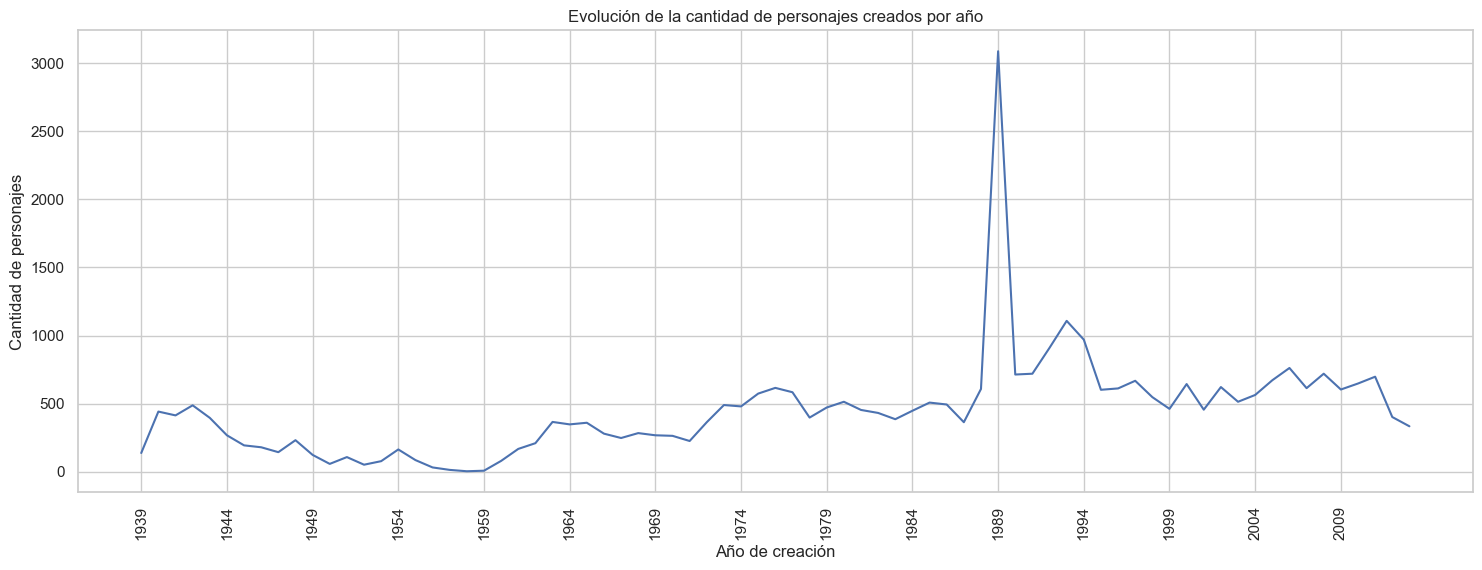

In [69]:
# Agrupar por año
personajes_por_anio = df_total.groupby('Year').size().reset_index(name='count')
personajes_por_anio = personajes_por_anio.rename(columns={'Year': 'anio'})

plt.figure(figsize=(18, 6))
sns.lineplot(data=personajes_por_anio, x='anio', y='count')

plt.xticks(
    ticks=range(int(personajes_por_anio['anio'].min()), 
                int(personajes_por_anio['anio'].max()) + 1, 5),
    rotation=90
)

plt.title("Evolución de la cantidad de personajes creados por año")
plt.xlabel("Año de creación")
plt.ylabel("Cantidad de personajes")
plt.show()

Hubo un aumento repentio en la cantidad de personajes creados por año, alcanzando un pico absurdo de personajes en el año de 1989.

### EJERCICIO 2. Mapa de calor: Relación entre alineación y estado vivo/fallecido

- Analiza la relación entre la alineación del personaje (ALIGN) y su estado (ALIVE).
- Muestra un mapa de calor que cuente cuántos personajes de cada tipo (Bueno, Malo, Neutral) están vivos o fallecidos.
- Saca una conclusión del gráfico.


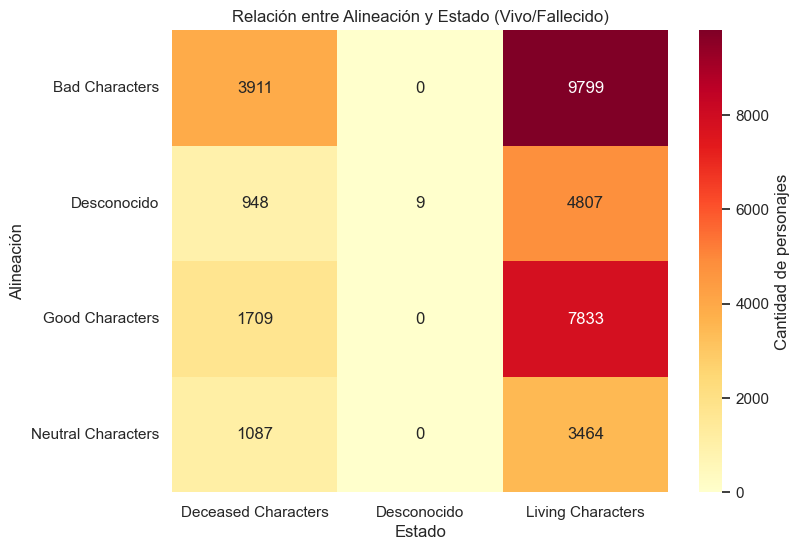

In [70]:
contingencia = pd.crosstab(df_total['ALIGN'], df_total['ALIVE'])

plt.figure(figsize=(8, 6))
sns.heatmap(contingencia, annot=True, fmt='d', cmap='YlOrRd', 
            cbar_kws={'label': 'Cantidad de personajes'})
plt.title("Relación entre Alineación y Estado (Vivo/Fallecido)")
plt.xlabel("Estado")
plt.ylabel("Alineación")
plt.show()

La mayoría de los personajes de Marvel están vivos, independientemente de su alineación. Los "Bad Characters" tienen la mayor cantidad de vivos (9,799) y también la mayor cantidad de fallecidos (3,911), lo que sugiere que los villanos mueren con más frecuencia que los héroes. Los "Good Characters" tienen 7,833 vivos y solo 1,709 fallecidos, lo que refleja la tendencia de mantener a los héroes con vida en el universo Marvel. Los "Neutral Characters" presentan una proporción similar, con mayoría de vivos (3,464) frente a fallecidos (1,087). La categoría "Desconocido" agrupa personajes sin información de alineación o estado.

### EJERCICIO 3. Histograma: Distribución del número de creación de personajes por décadas

- Analiza cómo se distribuyen la creación de los personas por décadas (Year).
- Crea un histograma cuantos personajes se crearon para cada década.


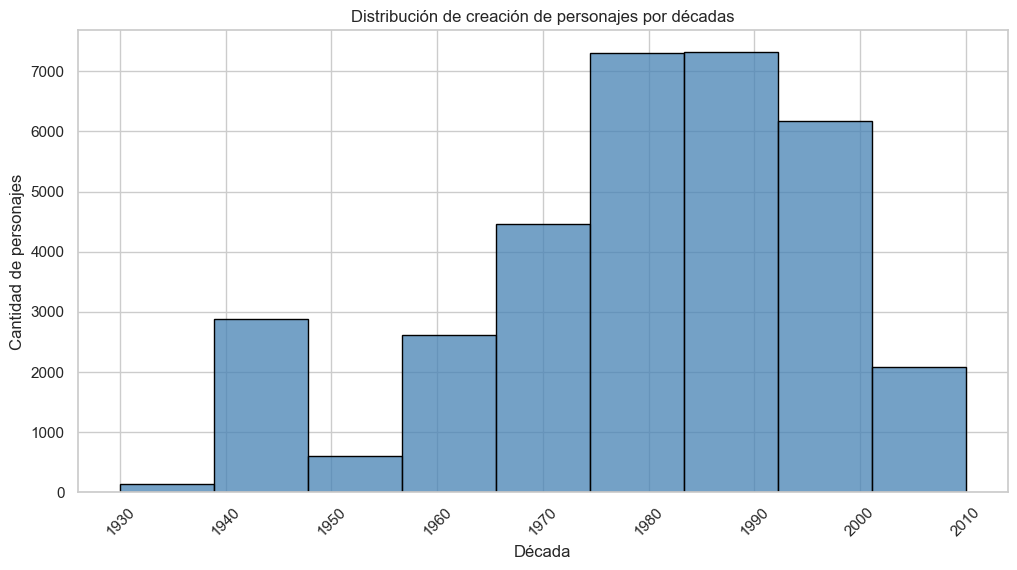

In [85]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df_total, x='DECADE', bins=len(df_total['DECADE'].unique()), 
             color='steelblue', edgecolor='black')

plt.xticks(rotation=45)
plt.title("Distribución de creación de personajes por décadas")
plt.xlabel("Década")
plt.ylabel("Cantidad de personajes")
plt.show()



Las décadas de 1980 y 1990 fueron las más productivas en creación de personajes de Marvel, seguidas por la década de 2000

### EJERCICIO 4. Crea 4 diagramas adicionales, diferentes a los ya usados en este deber e interpreta los resultados, cada uno deberia mostrar información relevante que considera el estudiante mostrar.

C:\Users\merce\AppData\Local\Temp\ipykernel_17716\1533364101.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_appearances, x='APPEARANCES', y='name', palette='rocket')


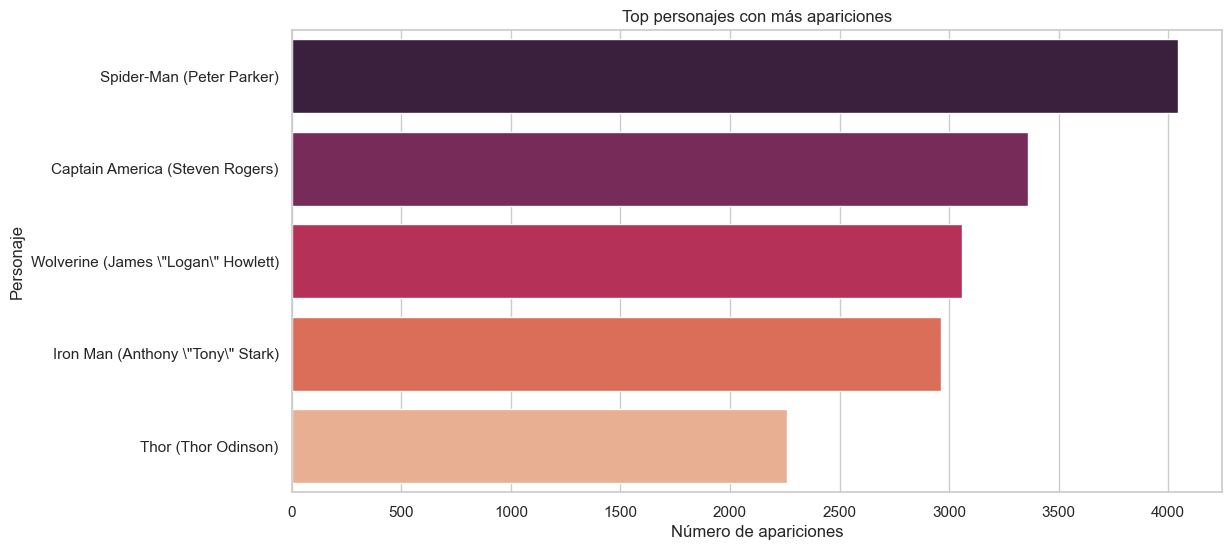

In [80]:
top_appearances = df_total.nlargest(10, 'APPEARANCES')[['name', 'APPEARANCES']]

plt.figure(figsize=(12, 6))
sns.barplot(data=top_appearances, x='APPEARANCES', y='name', palette='rocket')
plt.title("Top personajes con más apariciones")
plt.xlabel("Número de apariciones")
plt.ylabel("Personaje")
plt.show()

El presonaje con mayor numero de apariciones en los comics es Peter Parker alias Spider-Man

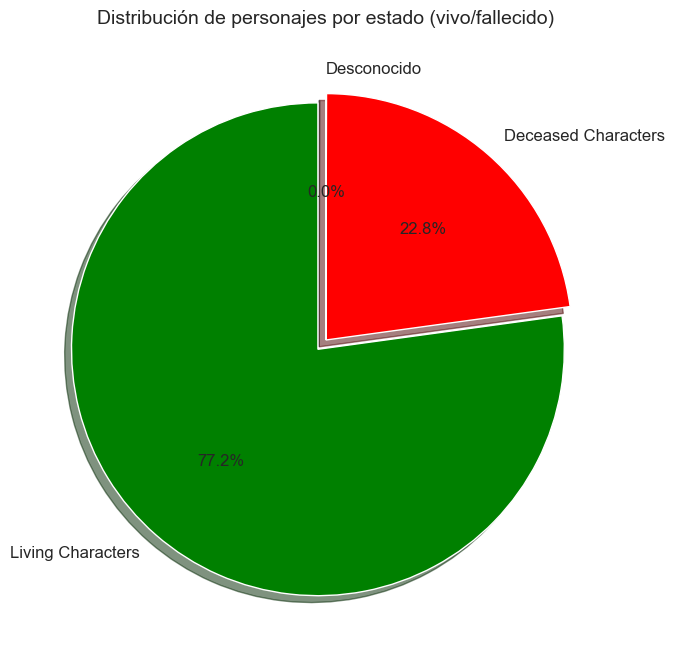

In [88]:
plt.figure(figsize=(8, 8))
alive_counts = df_total['ALIVE'].value_counts()

# Colores específicos para cada estado
colors_pie = ['green', 'red', 'gray']
explode = (0.05, 0, 0)  # Resaltar la porción de vivos

plt.pie(alive_counts.values, 
        labels=alive_counts.index, 
        autopct='%1.1f%%', 
        colors=colors_pie, 
        startangle=90, 
        explode=explode,
        shadow=True,
        textprops={'fontsize': 12})

plt.title("Distribución de personajes por estado (vivo/fallecido)", fontsize=14)
plt.show()

La mayoría de los personajes de Marvel están vivos, lo que permite su reutilización en nuevas historias y crossovers.

C:\Users\merce\AppData\Local\Temp\ipykernel_17716\3706597722.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_hair.index, y=top_hair.values, palette='coolwarm')


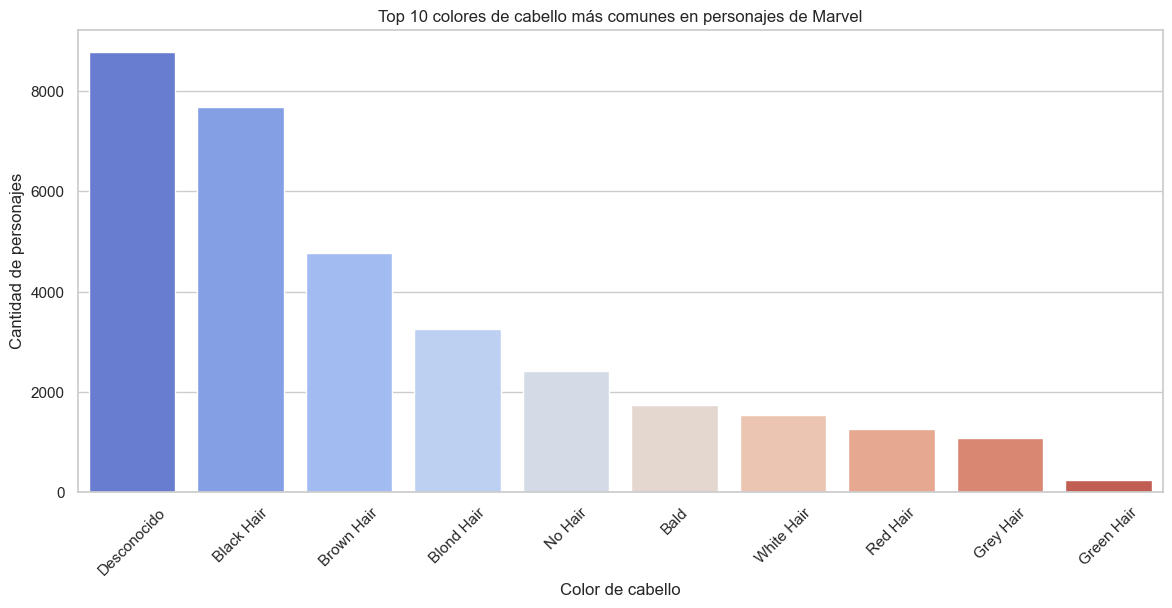

In [87]:
plt.figure(figsize=(14, 6))
top_hair = df_total['HAIR'].value_counts().head(10)
sns.barplot(x=top_hair.index, y=top_hair.values, palette='coolwarm')
plt.title('Top 10 colores de cabello más comunes en personajes de Marvel')
plt.xlabel('Color de cabello')
plt.ylabel('Cantidad de personajes')
plt.xticks(rotation=45)
plt.show()

El color de cabello mas comun de los personajes es en realiad desconocido, pero segundo mas comun es el cabello negro.

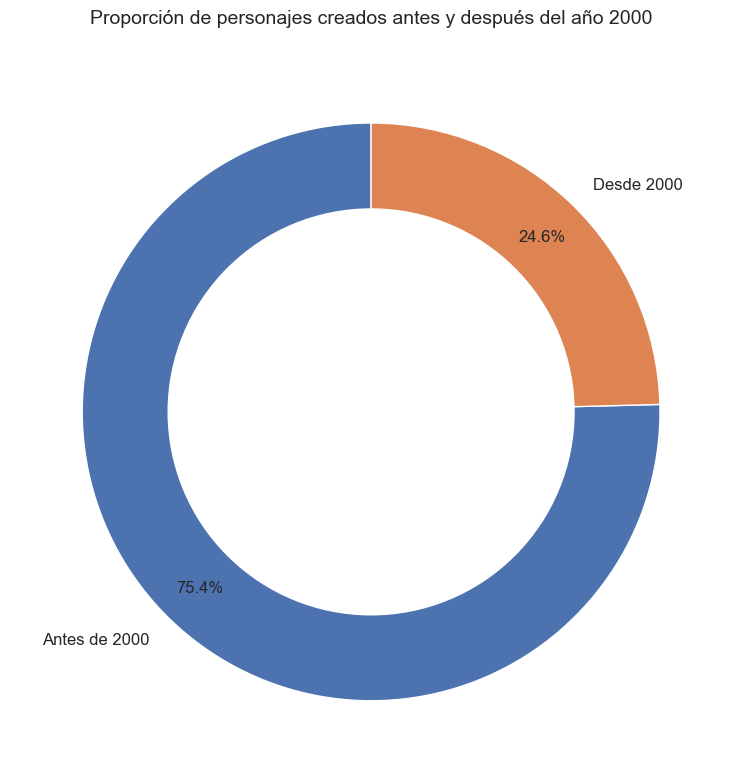

In [101]:
# Crear categoría temporal
df_total['periodo'] = df_total['Year'].apply(lambda x: 'Antes de 2000' if x < 2000 else 'Desde 2000')

# Contar personajes por período
periodo_counts = df_total['periodo'].value_counts()

plt.figure(figsize=(10, 8))
# Crear gráfico de dona
wedges, texts, autotexts = plt.pie(periodo_counts.values, 
                                     labels=periodo_counts.index,
                                     autopct='%1.1f%%',
                                     startangle=90,
                                     pctdistance=0.85,
                                     textprops={'fontsize': 12})

# Agregar círculo central para efecto "dona"
centre_circle = plt.Circle((0, 0), 0.70, fc='white', linewidth=2, edgecolor='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Proporción de personajes creados antes y después del año 2000", fontsize=14, pad=20)

plt.tight_layout()
plt.show()



La mayoría de los personajes de Marvel fueron creados antes del año 2000, lo cual coincide con la 'Edad de Plata' y 'Edad de Bronce' de los cómics.
Sin embargo, casi un tercio de los personajes de marvel fueron creado desde el año 2000, impulsado por la expansión del universo Marvel en cine y nuevas series de cómics.